# Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# EDA

In [2]:
# Load the summary dataset
df = pd.read_csv(r'C:\Users\kerem\OneDrive\Masaüstü\VsCodeProjects\BLG610E_HomeWorks\project\datasets\master_dataset.csv')
df.head()

,Year,Region,Rural,Urban,Total_Population,Total_Births,Net_Migration
0,2013,"Adana, Mersin-TR62",0.0,3855034.0,3855034.0,66659,-16349
1,2014,"Adana, Mersin-TR62",0.0,3892850.0,3892850.0,69077,-10864
2,2015,"Adana, Mersin-TR62",0.0,3928388.0,3928388.0,67982,-13778
3,2016,"Adana, Mersin-TR62",0.0,3975522.0,3975522.0,66331,-7094
4,2017,"Adana, Mersin-TR62",0.0,4010406.0,4010406.0,64830,-14226


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              312 non-null    int64  
 1   Region            312 non-null    str    
 2   Rural             312 non-null    float64
 3   Urban             312 non-null    float64
 4   Total_Population  312 non-null    float64
 5   Total_Births      312 non-null    int64  
 6   Net_Migration     312 non-null    int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 17.2 KB


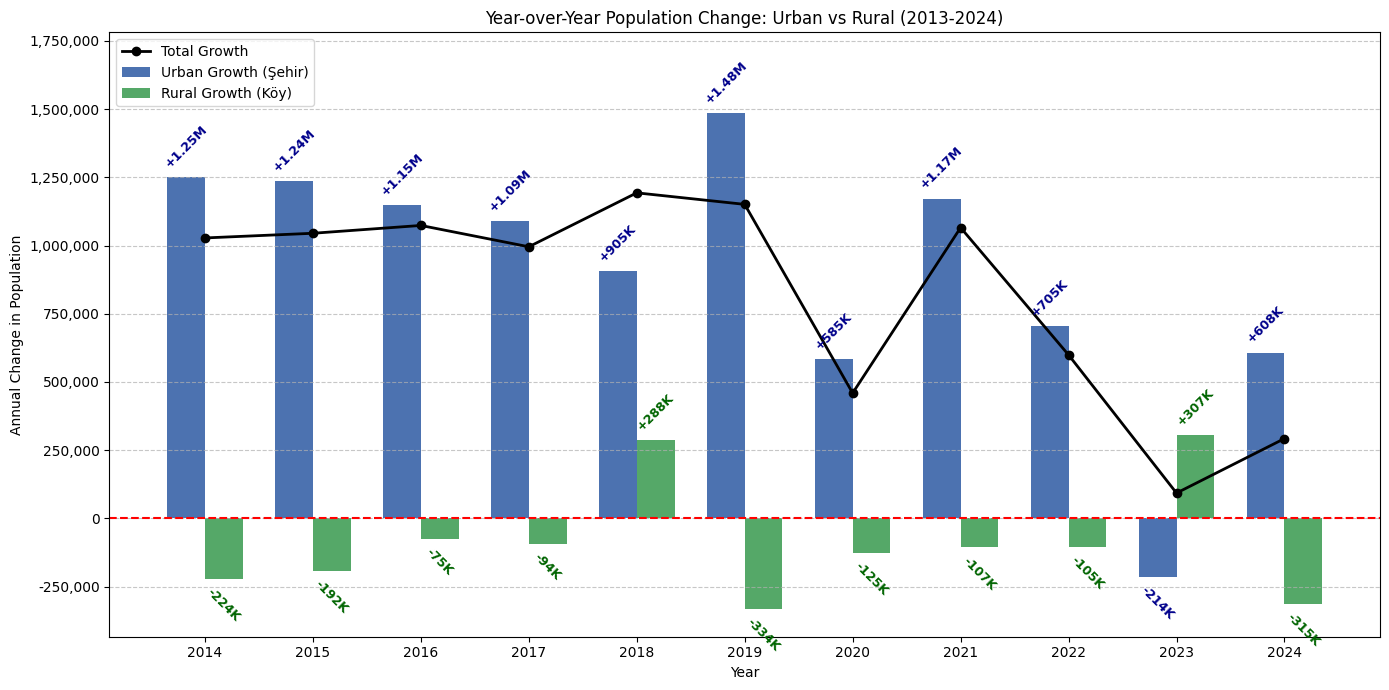

In [ ]:
national_trend = df.groupby('Year')[['Urban', 'Rural', 'Total_Population']].sum().reset_index()

national_trend['Urban_Change'] = national_trend['Urban'].diff()
national_trend['Rural_Change'] = national_trend['Rural'].diff()
national_trend['Total_Change'] = national_trend['Total_Population'].diff()

migration_era = national_trend.dropna().copy()

plt.figure(figsize=(14, 7))
x = np.arange(len(migration_era['Year']))
width = 0.35

bars_urban = plt.bar(x - width/2, migration_era['Urban_Change'], width, label='Urban Growth (Şehir)', color='#4C72B0')
bars_rural = plt.bar(x + width/2, migration_era['Rural_Change'], width, label='Rural Growth (Köy)', color='#55A868')

plt.plot(x, migration_era['Total_Change'], color='black', marker='o', linestyle='-', linewidth=2, label='Total Growth')

plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))

def format_delta(val):
    if pd.isna(val) or val == 0:
        return ""
    sign = "+" if val > 0 else ""
    if abs(val) >= 1_000_000:
        return f"{sign}{val/1_000_000:.2f}M"
    else:
        return f"{sign}{val/1_000:.0f}K"

# Urban
for i, bar in enumerate(bars_urban):
    delta = migration_era['Urban_Change'].iloc[i]
    label = format_delta(delta)
    if label:
        y_pos = bar.get_height()
        va = 'bottom' if y_pos > 0 else 'top'
        offset = 5 if y_pos > 0 else -5
        plt.annotate(label,
                     xy=(bar.get_x() + bar.get_width() / 2, y_pos),
                     xytext=(0, offset),
                     textcoords="offset points",
                     ha='center', va=va, fontsize=9, color='darkblue', fontweight='bold', 
                     rotation=45 if y_pos > 0 else -45)
        
# Rural
for i, bar in enumerate(bars_rural):
    delta = migration_era['Rural_Change'].iloc[i]
    label = format_delta(delta)
    if label:
        y_pos = bar.get_height()
        va = 'bottom' if y_pos > 0 else 'top'
        offset = 5 if y_pos > 0 else -5
        plt.annotate(label,
                     xy=(bar.get_x() + bar.get_width() / 2, y_pos),
                     xytext=(0, offset),
                     textcoords="offset points",
                     ha='center', va=va, fontsize=9, color='darkgreen', fontweight='bold', 
                     rotation=45 if y_pos > 0 else -45)

plt.title('Year-over-Year Population Change: Urban vs Rural (2013-2024)')
plt.xlabel('Year')
plt.ylabel('Annual Change in Population')
plt.xticks(x, migration_era['Year'].astype(int))

max_val = max(migration_era['Urban_Change'].max(), migration_era['Total_Change'].max())
min_val = migration_era['Rural_Change'].min()
plt.ylim(min_val * 1.3 if min_val < 0 else 0, max_val * 1.2)

plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

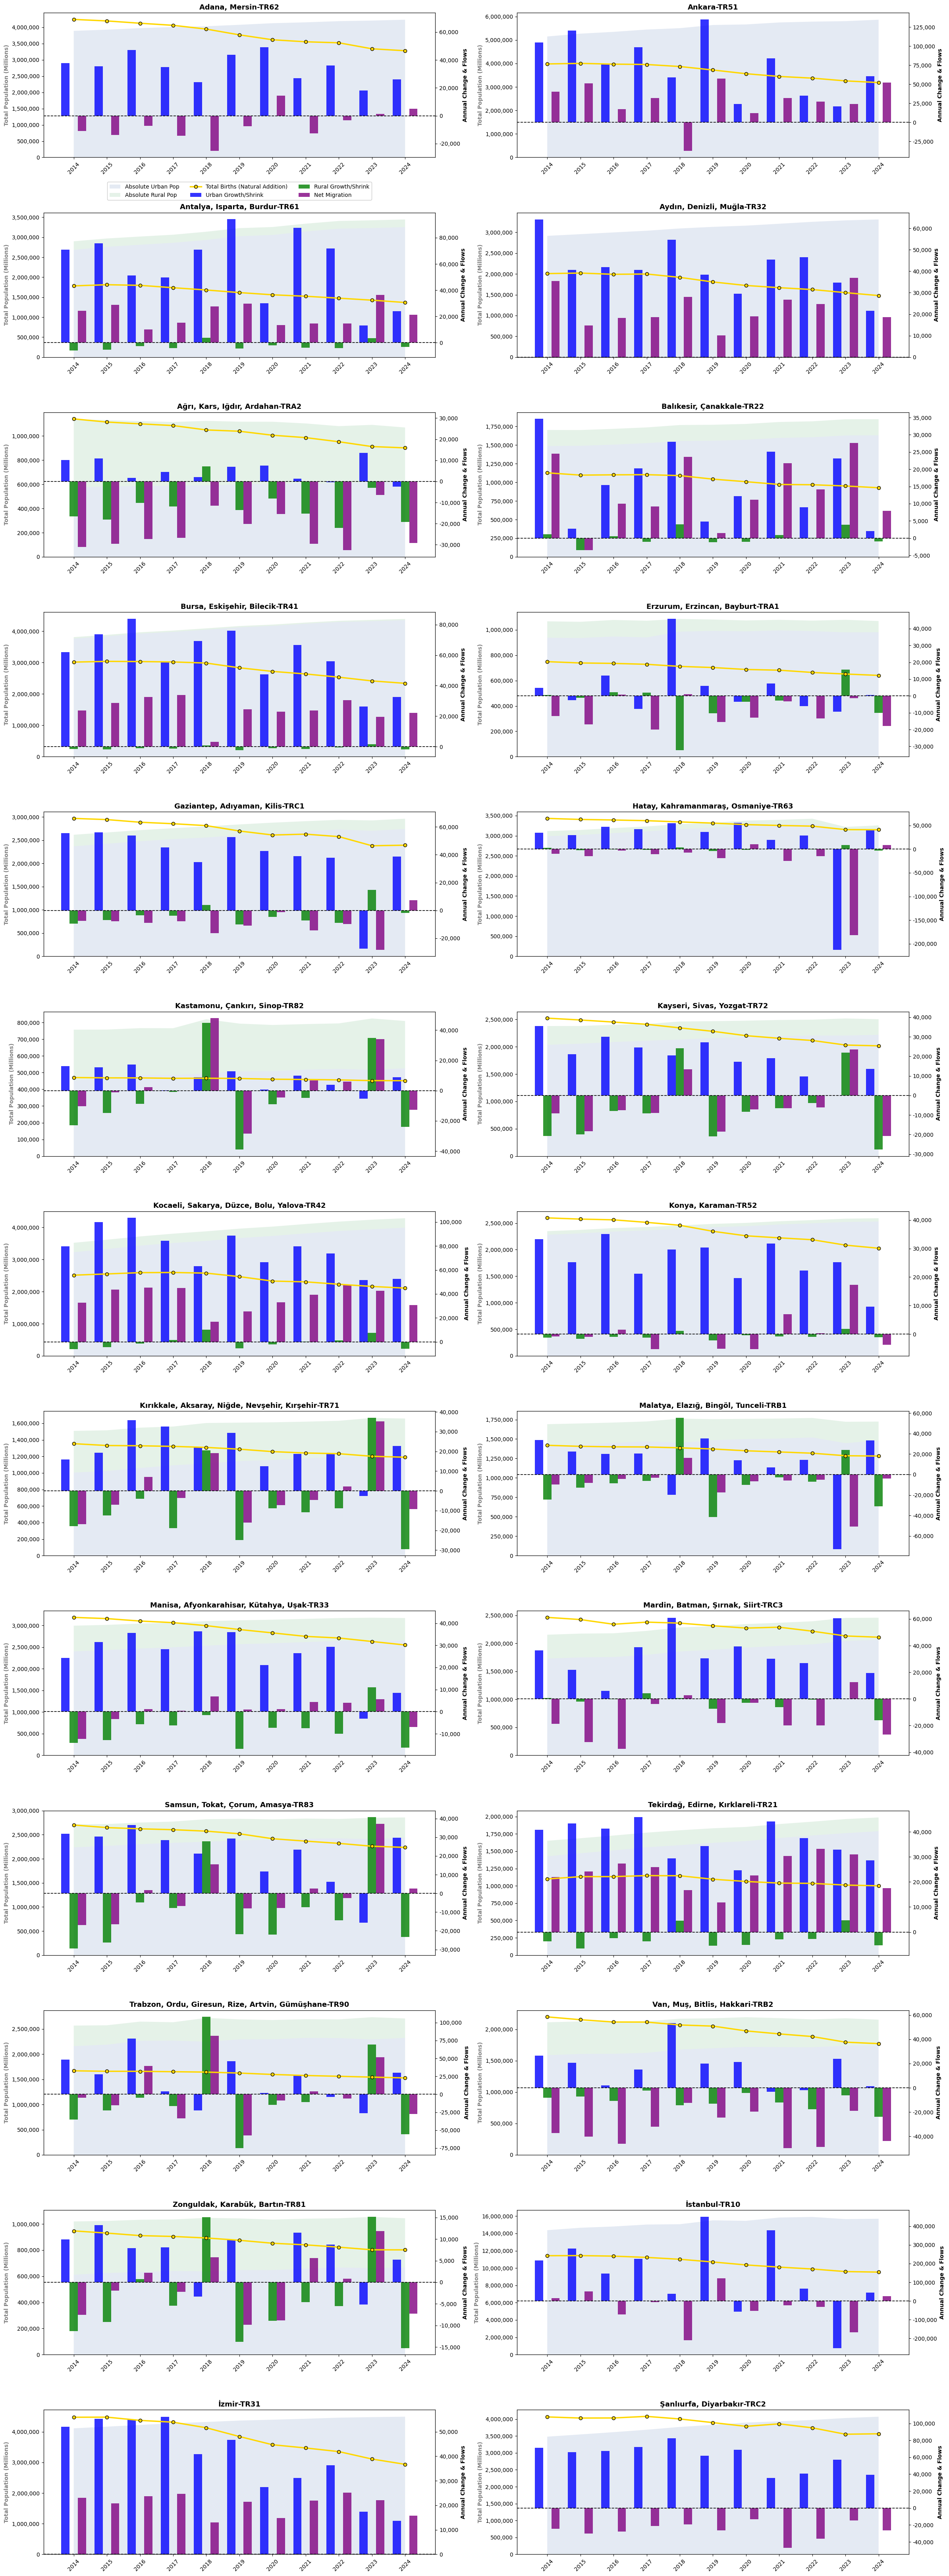

In [5]:
regions = sorted(df['Region'].unique())

fig, axes = plt.subplots(nrows=13, ncols=2, figsize=(24, 65))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax1 = axes[i]
    
    region_data = df[df['Region'] == region].copy()
    region_data['Urban_Change'] = region_data['Urban'].diff()
    region_data['Rural_Change'] = region_data['Rural'].diff()
    
    region_data = region_data.dropna().reset_index(drop=True)
    
    years = region_data['Year'].astype(int)
    x = np.arange(len(years))
    
    ax1.stackplot(x, region_data['Urban'], region_data['Rural'], 
                  labels=['Absolute Urban Pop', 'Absolute Rural Pop'], 
                  colors=['#4C72B0', '#55A868'], alpha=0.15)
    
    ax1.set_ylabel('Total Population (Millions)', color='gray', fontweight='bold')
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))
    
    ax2 = ax1.twinx()
    width = 0.25
    
    ax2.bar(x - width, region_data['Urban_Change'], width, label='Urban Growth/Shrink', color='blue', alpha=0.8)
    ax2.bar(x, region_data['Rural_Change'], width, label='Rural Growth/Shrink', color='green', alpha=0.8)
    ax2.bar(x + width, region_data['Net_Migration'], width, label='Net Migration', color='purple', alpha=0.8)
    
    ax2.plot(x, region_data['Total_Births'], color='#FFD700', marker='o', 
             linewidth=2.5, markersize=6, label='Total Births (Natural Addition)', markeredgecolor='black')
    
    ax2.set_ylabel('Annual Change & Flows', color='black', fontweight='bold')
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))
    
    ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(years, rotation=45)
    ax1.set_title(region, fontsize=13, fontweight='bold')
    
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', 
                   bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=3, framealpha=1)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()